# Car Price Prediction 

# Importing The Dependicies

In [47]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")
import plotly.graph_objects as go
import plotly.io as pio 
pio.renderers.default='notebook_connected'


In [2]:
df=pd.read_csv("ford.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


# Data cleaning , preprocessing and EDA

In [3]:
df.shape

(17966, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [48]:
df.describe

<bound method NDFrame.describe of          model  year  price transmission  mileage fuelType  tax   mpg  \
0       Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7   
1        Focus  2018  14000       Manual     9083   Petrol  150  57.7   
2        Focus  2017  13000       Manual    12456   Petrol  150  57.7   
3       Fiesta  2019  17500       Manual    10460   Petrol  145  40.3   
4       Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7   
...        ...   ...    ...          ...      ...      ...  ...   ...   
17961    B-MAX  2017   8999       Manual    16700   Petrol  150  47.1   
17962    B-MAX  2014   7499       Manual    40700   Petrol   30  57.7   
17963    Focus  2015   9999       Manual     7010   Diesel   20  67.3   
17964       KA  2018   8299       Manual     5007   Petrol  145  57.7   
17965    Focus  2015   8299       Manual     5007   Petrol   22  57.7   

       engineSize  
0             1.0  
1             1.0  
2             1.0  
3        

In [6]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [7]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [8]:
df1=df.copy()

In [14]:
df1.shape

(17966, 9)

In [15]:
df1.duplicated().sum()

np.int64(154)

In [19]:
df1=df1.drop_duplicates().reset_index(drop=True)
df1.shape

(17812, 9)

In [20]:
df1['model'].value_counts()

model
 Fiesta                   6509
 Focus                    4555
 Kuga                     2208
 EcoSport                 1127
 C-MAX                     542
 Ka+                       523
 Mondeo                    512
 B-MAX                     350
 S-MAX                     294
 Grand C-MAX               247
 Galaxy                    227
 Edge                      205
 KA                        197
 Puma                       79
 Tourneo Custom             69
 Mustang                    57
 Grand Tourneo Connect      57
 Tourneo Connect            32
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64

In [21]:
df1[df1['price']<=0].count()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

<Axes: xlabel='price'>

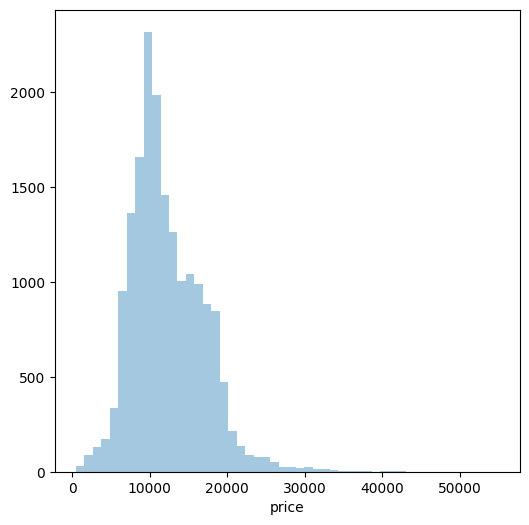

In [22]:
fig, ax = plt.subplots(figsize=(6,6))
sns.distplot(df1['price'],kde=False)

In [27]:
a=df1.groupby('model')['price'].sum().reset_index()
a1=a.sort_values(by='price',ascending=False)[['model','price']].head(10)
a1

,model,price
5,Fiesta,66332283
6,Focus,60030224
13,Kuga,34928705
2,EcoSport,14052864
14,Mondeo,6276581
1,C-MAX,5373119
18,S-MAX,5190688
3,Edge,4655584
12,Ka+,4549602
8,Galaxy,4051648


<Axes: xlabel='model', ylabel='price'>

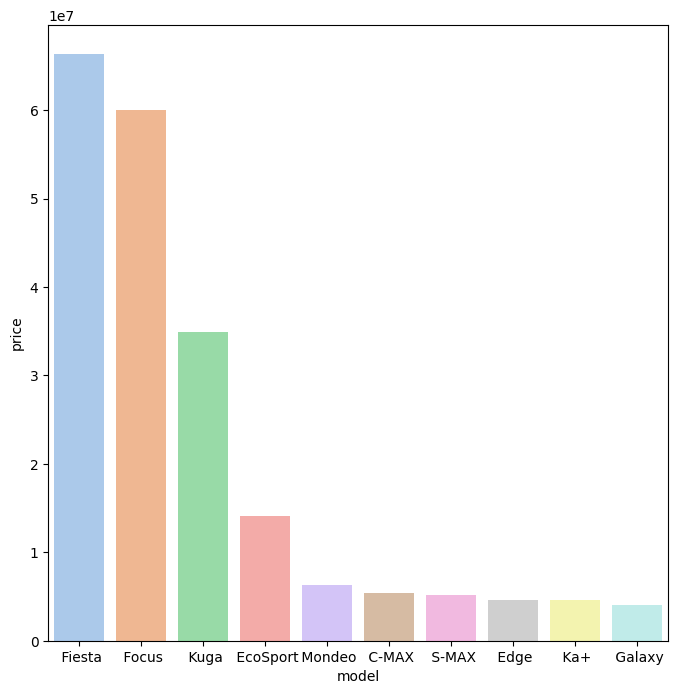

In [32]:
fig,ax=plt.subplots(figsize=(8,8))
sns.barplot(x='model',y='price',data=a1,ax=ax,palette='pastel')

In [34]:
b=df1.groupby('year')['price'].sum().reset_index()
b=b.drop(22)
b

,year,price
0,1996,3000
1,1998,2699
2,2000,1995
3,2002,5785
4,2003,6189
5,2004,5744
6,2005,25488
7,2006,28634
8,2007,83314
9,2008,146342


In [51]:
fig=go.Figure([go.Scatter(x=b['year'],y=b['price'])])
fig.update_layout(title='Time Series Graph of price of cars year wise',
                  xaxis_title='year',  # Set the x-axis label
                  yaxis_title='Price of cars')
fig.show()

In [52]:
c=df1.groupby('transmission')['price'].sum().reset_index()
c1=c.sort_values(by='price')
c1

,transmission,price
2,Semi-Auto,16015323
0,Automatic,21262532
1,Manual,181267482


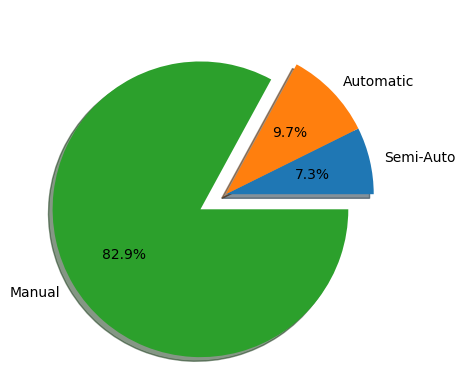

In [53]:
y=c1['price']
labels=['Semi-Auto','Automatic','Manual']
myexplode=[0,0,0.2]
plt.pie(y,labels=labels,explode = myexplode,shadow=True,autopct='%1.1f%%')
plt.show()

In [54]:
d=df1.groupby('fuelType')['tax'].sum().reset_index()
d1=d.sort_values(by='tax')
d1

,fuelType,tax
1,Electric,0
3,Other,0
2,Hybrid,2215
0,Diesel,580305
4,Petrol,1435847


In [55]:
x_values = d1['fuelType']
y_values = d1['tax']
bubble_size = [10, 20, 30, 40, 50]
bubble_color = ['blue', 'green', 'red', 'yellow', 'purple']
scatter_plot = go.Scatter(x=x_values, y=y_values, mode='markers',marker=dict(size=bubble_size, color=bubble_color))
fig = go.Figure(scatter_plot)
fig.update_layout(
    title='Tax paid for various fuel type',
    xaxis_title='Fuel Type',
    yaxis_title='Tax Amount'
)
fig.show()

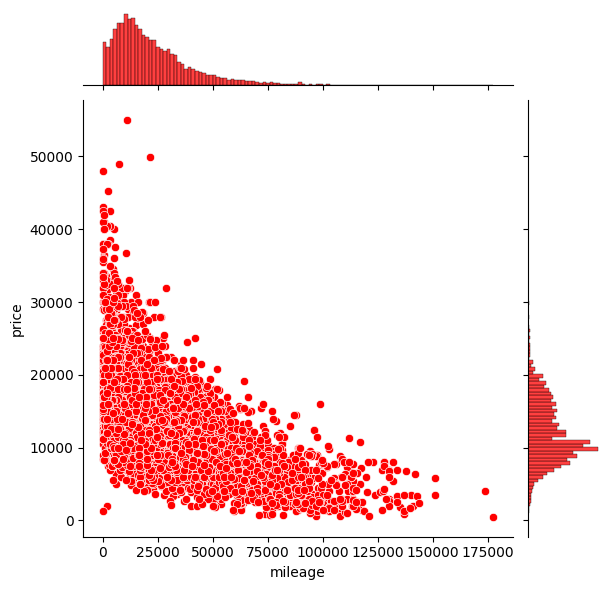

In [58]:
sns.jointplot(data=df1, x=df1['mileage'], y=df1['price'],color='r')

<Axes: >

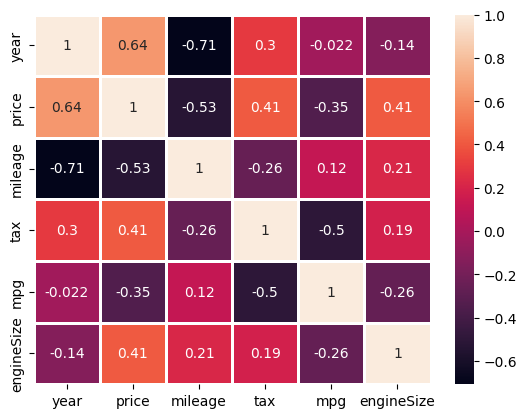

In [61]:
sns.heatmap(df1.corr(numeric_only=True),annot=True,linewidths=1)

# Feature Engineering and Scaling

In [73]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [64]:
X=df1.drop('price',axis=1)
y=df1['price']

In [65]:
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17807,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17808,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17809,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17810,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [67]:
le=LabelEncoder()
columns=['model','transmission','fuelType']
for col in columns: 
    X[col]=le.fit_transform(X[col])

In [79]:
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17807,0,2017,1,16700,4,150,47.1,1.4
17808,0,2014,1,40700,4,30,57.7,1.0
17809,6,2015,1,7010,0,20,67.3,1.6
17810,11,2018,1,5007,4,145,57.7,1.2


In [81]:
#scaling using standard scaler
ms=MinMaxScaler()
X_ms=ms.fit_transform(X)


In [90]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['year', 'mileage', 'mpg','engineSize']
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

In [91]:
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,0.067059,0,-0.382994,4,150,-0.020597,-0.810561
1,6,0.554393,1,-0.736317,4,150,-0.020597,-0.810561
2,6,0.067059,1,-0.562616,4,150,-0.020597,-0.810561
3,5,1.041726,1,-0.665405,4,145,-1.737858,0.345325
4,5,1.041726,0,-1.127749,4,145,-0.908836,-0.810561
...,...,...,...,...,...,...,...,...
17807,0,0.067059,1,-0.344061,4,150,-1.066745,0.114148
17808,0,-1.394942,1,0.891875,4,30,-0.020597,-0.810561
17809,6,-0.907608,1,-0.843071,0,20,0.926858,0.576502
17810,11,0.554393,1,-0.946220,4,145,-0.020597,-0.348206


In [95]:
#Performing train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

In [99]:
#model building using Linear regression
mlr=LinearRegression()
mlr.fit(X_train,y_train)
y_pred=mlr.predict(X_test)
y_pred

array([19743.83972635, 18253.13830937, 17448.11730824, ...,
       11683.22573171, 14601.24635879, 10278.46057461], shape=(5344,))

In [98]:
#model validation for Linear Regression
import numpy as np
print("mean absolute error:",mean_absolute_error(y_test,y_pred))
print("mean squared error:",mean_squared_error(y_test,y_pred))
print("root mean squared error:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("r2-score:",r2_score(y_test,y_pred))

mean absolute error: 1744.4062565534555
mean squared error: 6111403.35724943
root mean squared error: 2472.1252713504286
r2-score: 0.7195451674275318
